In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix,ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA

df=pd.read_csv('Zoo.csv')
df

,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,wallaby,1,0,0,1,0,0,0,1,1,1,0,0,2,1,0,1,1
97,wasp,1,0,1,0,1,0,0,0,0,1,1,0,6,0,0,0,6
98,wolf,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
99,worm,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,7


In [36]:
df.head()

,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [37]:
df.describe()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,0.425743,0.198020,0.584158,0.405941,0.237624,0.356436,0.554455,0.603960,0.821782,0.792079,0.079208,0.168317,2.841584,0.742574,0.128713,0.435644,2.831683
std,0.496921,0.400495,0.495325,0.493522,0.427750,0.481335,0.499505,0.491512,0.384605,0.407844,0.271410,0.376013,2.033385,0.439397,0.336552,0.498314,2.102709
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,2.000000
75%,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,1.000000,4.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000,1.000000,1.000000,1.000000,7.000000


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   animal name  101 non-null    object
 1   hair         101 non-null    int64 
 2   feathers     101 non-null    int64 
 3   eggs         101 non-null    int64 
 4   milk         101 non-null    int64 
 5   airborne     101 non-null    int64 
 6   aquatic      101 non-null    int64 
 7   predator     101 non-null    int64 
 8   toothed      101 non-null    int64 
 9   backbone     101 non-null    int64 
 10  breathes     101 non-null    int64 
 11  venomous     101 non-null    int64 
 12  fins         101 non-null    int64 
 13  legs         101 non-null    int64 
 14  tail         101 non-null    int64 
 15  domestic     101 non-null    int64 
 16  catsize      101 non-null    int64 
 17  type         101 non-null    int64 
dtypes: int64(17), object(1)
memory usage: 14.3+ KB


In [39]:
df.isnull().sum()

,0
animal name,0
hair,0
feathers,0
eggs,0
milk,0
airborne,0
aquatic,0
predator,0
toothed,0
backbone,0


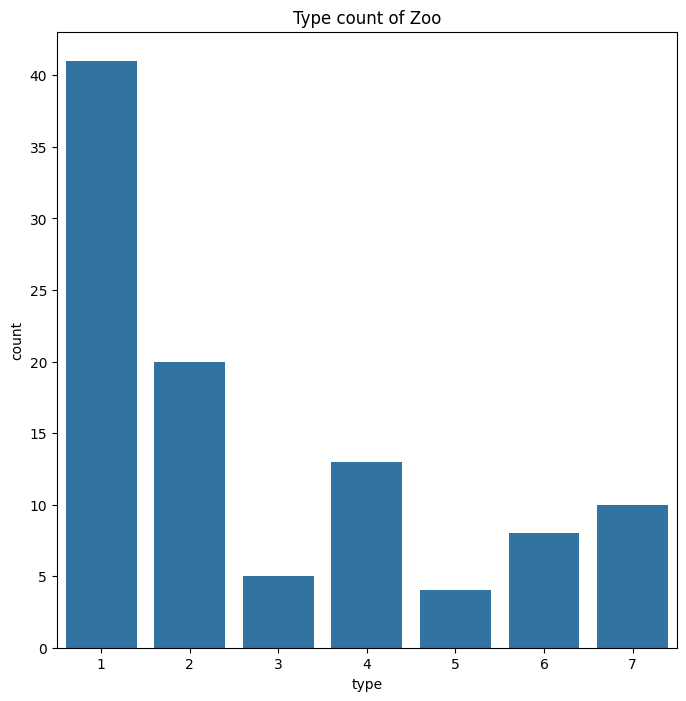

In [40]:
plt.figure(figsize=(8,8))
sns.countplot(x='type',data=df)
plt.title('Type count of Zoo')
plt.show()

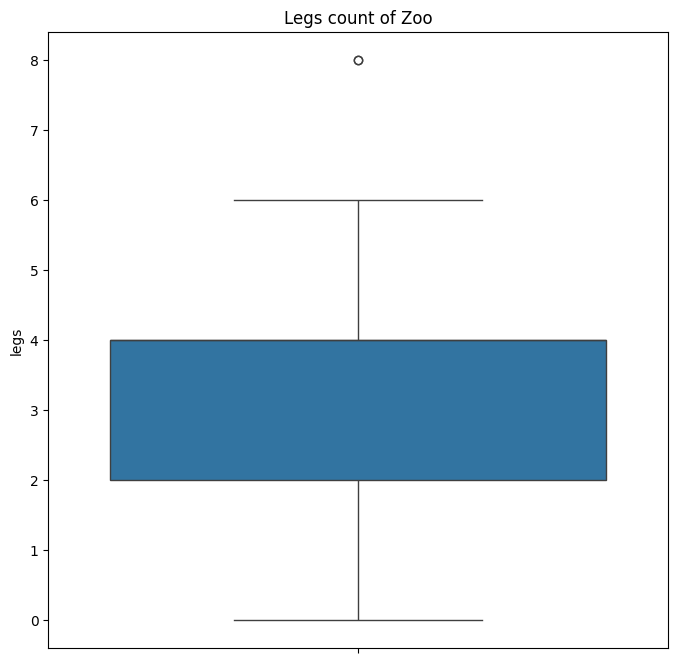

In [41]:
plt.figure(figsize=(8,8))
sns.boxplot(y='legs',data=df)
plt.title('Legs count of Zoo')
plt.show()

In [42]:
x=df.drop(columns=['animal name','type'])
y=df['type']

In [43]:
from numpy.random import RandomState
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [44]:
sc=StandardScaler()
x_scaled=sc.fit_transform(x_train)
x_test_scaled=sc.transform(x_test)

In [45]:
param_grid = {'n_neighbors': np.arange(1, 16, 2),
              'metric': ['minkowski'],
              'p': [2]}
knn = KNeighborsClassifier()
gs  = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
gs.fit(x_scaled, y_train)

print(f'Best k: {gs.best_params_["n_neighbors"]}')
best_knn = gs.best_estimator_

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Best k: 1



Accuracy: 1.0

Classification report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         2

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



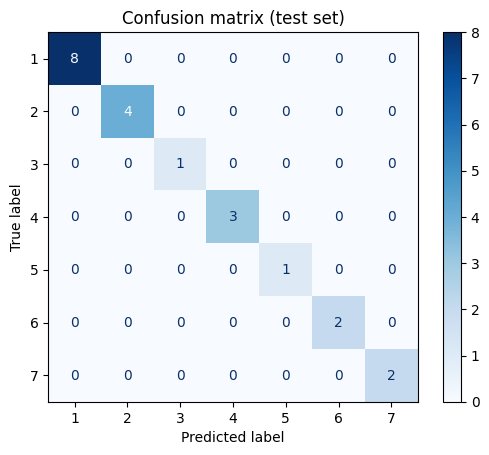

In [46]:
y_pred = best_knn.predict(x_test_scaled)

print('\nAccuracy:', round(accuracy_score(y_test, y_pred), 3))
print('\nClassification report:\n', classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=best_knn.classes_)
ConfusionMatrixDisplay(cm, display_labels=best_knn.classes_).plot(cmap='Blues')
plt.title('Confusion matrix (test set)')
plt.show()

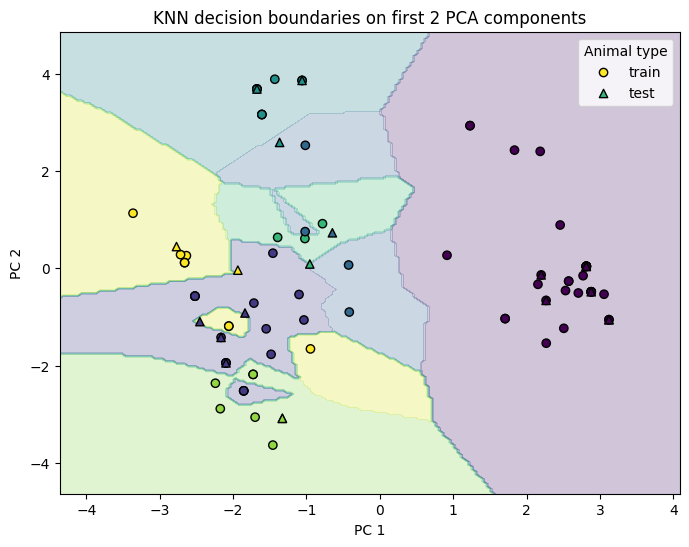

In [49]:
pca = PCA(n_components=2, random_state=42)
x_train_pca = pca.fit_transform(x_scaled)
x_test_pca  = pca.transform(x_test_scaled)

knn_2d = KNeighborsClassifier(n_neighbors=gs.best_params_["n_neighbors"])
knn_2d.fit(x_train_pca, y_train)

x_min, x_max = x_train_pca[:,0].min()-1, x_train_pca[:,0].max()+1
y_min, y_max = x_train_pca[:,1].min()-1, x_train_pca[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.25)
scatter = plt.scatter(x_train_pca[:,0], x_train_pca[:,1],
                      c=y_train, edgecolor='k', marker='o', label='train')
plt.scatter(x_test_pca[:,0], x_test_pca[:,1],
            c=y_test, edgecolor='k', marker='^', label='test')
plt.legend(title='Animal type')
plt.title('KNN decision boundaries on first 2 PCA components')
plt.xlabel('PC 1'); plt.ylabel('PC 2')
plt.show()

In [50]:
df.isnull().sum()

,0
animal name,0
hair,0
feathers,0
eggs,0
milk,0
airborne,0
aquatic,0
predator,0
toothed,0
backbone,0


In [51]:
df.fillna(df.median(numeric_only=True),inplace=True)

In [54]:
for col in df.select_dtypes(include='number').columns:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)
  IQR=Q3-Q1
  lower_bound=Q1-1.5*IQR
  upper_bound=Q3+1.5*IQR
  df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
print(" Missing values handled and outliers capped.")

 Missing values handled and outliers capped.


'''
##  What are the key hyperparameters in KNN?

| Hyperparameter     | Description                                                           |
|--------------------|------------------------------------------------------------------------|
| `n_neighbors`      | Number of nearest neighbors to consider for classification/regression |
| `weights`          | Uniform (equal weight) or distance-based weighting                    |
| `metric`           | Distance metric to use (e.g., Euclidean, Manhattan, Minkowski)         |
| `algorithm`        | Algorithm used to compute neighbors (auto, ball_tree, kd_tree, brute) |
| `leaf_size`        | Leaf size passed to BallTree or KDTree                                |

Choosing optimal `n_neighbors` and the right `metric` is key to improving model performance.
'''

'''
## What distance metrics can be used in KNN?

KNN supports several distance metrics. Common ones include:

- Euclidean Distance  
- Manhattan Distance
- Minkowski Distance  
- Hamming Distance
The choice of distance metric affects how neighbors are defined and ultimately impacts the classification accuracy.
'''